# FPPool Benchmark

This notebook compares a standard Chemprop aggregation baseline against the current
FPPool implementation on a small bundled regression dataset. The goal is
operational validation, not a claim-heavy benchmark.

Supported scope for this notebook:

- molecule-only inputs
- single-component inputs
- multi-family FPPool using the synthetic atomic special family plus Morgan, RDKit, and PubChem memberships
- CPU-safe execution

In [1]:
from pathlib import Path
import tempfile

from IPython.display import display
from lightning import pytorch as pl
import pandas as pd
import torch
from torch.utils.data import DataLoader

from chemprop import models, nn
from chemprop.cli.utils import build_data_from_files
from chemprop.data import FPPoolConfig, MoleculeDatapoint, MoleculeDataset, collate_batch
from chemprop.interpret import (
    draw_fppool_inner_explanations,
    extract_fppool_explanation,
    plot_fppool_global_weights,
    plot_fppool_inter_summary,
)


In [2]:
chemprop_dir = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
input_path = chemprop_dir / "tests" / "data" / "regression" / "mol" / "mol.csv"
df = pd.read_csv(input_path)
df.head()


,smiles,lipo
0,Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14,3.54
1,COc1cc(OC)c(cc1NC(=O)CSCC(=O)O)S(=O)(=O)N2C(C)...,-1.18
2,COC(=O)[C@@H](N1CCc2sccc2C1)c3ccccc3Cl,3.69
3,OC[C@H](O)CN1C(=O)C(Cc2ccccc12)NC(=O)c3cc4cc(C...,3.37
4,Cc1cccc(C[C@H](NC(=O)c2cc(nn2C)C(C)(C)C)C(=O)N...,3.10


In [3]:
smis = df["smiles"].tolist()
ys = df["lipo"].to_numpy().reshape(-1, 1)
benchmark_fppool_config = FPPoolConfig(
    family_names=("morgan", "rdkit", "pubchem"),
    atoms_repr=True,
)

def make_baseline_loader() -> DataLoader:
    datapoints = [MoleculeDatapoint.from_smi(smi, y) for smi, y in zip(smis, ys)]
    dataset = MoleculeDataset(datapoints)
    dataset.normalize_targets()
    return DataLoader(dataset, batch_size=32, collate_fn=collate_batch)

def make_fppool_loader() -> DataLoader:
    with tempfile.TemporaryDirectory() as tmpdir:
        (datapoints,) = build_data_from_files(
            input_path,
            no_header_row=False,
            smiles_cols=["smiles"],
            rxn_cols=None,
            target_cols=["lipo"],
            ignore_cols=None,
            splits_col=None,
            weight_col=None,
            bounded=False,
            p_descriptors=None,
            p_atom_feats=None,
            p_bond_feats=None,
            p_atom_descs=None,
            descriptor_cols=None,
            molecule_featurizers=None,
            keep_h=False,
            add_h=False,
            ignore_stereo=False,
            reorder_atoms=True,
            use_cuikmolmaker_featurization=False,
            fppool_config=benchmark_fppool_config,
            fppool_cache_root=Path(tmpdir) / ".cache",
            n_workers=0,
        )
        dataset = MoleculeDataset(datapoints)
        dataset.normalize_targets()
        return DataLoader(dataset, batch_size=32, collate_fn=collate_batch)

In [4]:
def run_fast_dev(model, dataloader: DataLoader) -> float:
    trainer = pl.Trainer(
        logger=False,
        enable_checkpointing=False,
        enable_progress_bar=False,
        enable_model_summary=False,
        accelerator="cpu",
        devices=1,
        fast_dev_run=True,
    )
    trainer.fit(model, dataloader, None)
    batch = next(iter(dataloader))
    bmg, _, _, targets, *_, fppool_batch = batch
    preds = model(bmg, fppool_batch=fppool_batch)
    return torch.mean((preds - targets) ** 2).item()


In [5]:
baseline_loader = make_baseline_loader()
fppool_loader = make_fppool_loader()

baseline_model = models.MPNN(
    nn.BondMessagePassing(),
    nn.MeanAggregation(),
    nn.RegressionFFN(),
    batch_norm=True,
)
fppool_model = models.MPNN(
    nn.BondMessagePassing(),
    nn.FPPoolAggregation(),
    nn.RegressionFFN(),
    batch_norm=True,
)

baseline_mse = run_fast_dev(baseline_model, baseline_loader)
fppool_mse = run_fast_dev(fppool_model, fppool_loader)

pd.DataFrame(
    [
        {"aggregation": "mean", "fast_dev_run_mse": baseline_mse},
        {"aggregation": "fppool (atoms + morgan + rdkit + pubchem)", "fast_dev_run_mse": fppool_mse},
    ]
)

[13:24:45] DEPRECATION WARNING: please use MorganGenerator
[13:24:45] DEPRECATION WARNING: please use MorganGenerator
[13:24:45] DEPRECATION WARNING: please use MorganGenerator
[13:24:45] DEPRECATION WARNING: please use MorganGenerator
[13:24:45] DEPRECATION WARNING: please use MorganGenerator
[13:24:45] DEPRECATION WARNING: please use MorganGenerator
[13:24:45] DEPRECATION WARNING: please use MorganGenerator
[13:24:45] DEPRECATION WARNING: please use MorganGenerator
[13:24:45] DEPRECATION WARNING: please use MorganGenerator
[13:24:45] DEPRECATION WARNING: please use MorganGenerator
[13:24:45] DEPRECATION WARNING: please use MorganGenerator
[13:24:45] DEPRECATION WARNING: please use MorganGenerator
[13:24:45] DEPRECATION WARNING: please use MorganGenerator
[13:24:45] DEPRECATION WARNING: please use MorganGenerator
[13:24:45] DEPRECATION WARNING: please use MorganGenerator
[13:24:45] DEPRECATION WARNING: please use MorganGenerator
[13:24:45] DEPRECATION WARNING: please use MorganGenerat

,aggregation,fast_dev_run_mse
0,mean,0.782647
1,fppool (atoms + morgan + rdkit + pubchem),0.973800


## Interpretability preview

The public `chemprop.interpret` API remains family-agnostic. The example below rebuilds
explicit atom-and-bond provenance for the current `atoms + morgan + rdkit + pubchem`
configuration and then shows:

- the structured explanation payload
- one inner-level highlighted substructure view
- the inter-level family/bit summary
- the global family weights

In [6]:
fppool_batch = next(iter(fppool_loader))
bmg, _, _, _, *_, batch_fppool = fppool_batch
num_batch_mols = int(batch_fppool.molecule_atom_slices.numel() - 1)
batch_mols = [dp.mol for dp in fppool_loader.dataset.data[:num_batch_mols]]

_ = fppool_model(bmg, fppool_batch=batch_fppool)
explanations = extract_fppool_explanation(
    fppool_model,
    batch_mols,
    batch_fppool,
    benchmark_fppool_config,
    top_k_bits=3,
)
example_explanation = explanations[0]
example_explanation.global_explanation

[13:24:48] DEPRECATION WARNING: please use MorganGenerator
[13:24:48] DEPRECATION WARNING: please use MorganGenerator
[13:24:48] DEPRECATION WARNING: please use MorganGenerator
[13:24:48] DEPRECATION WARNING: please use MorganGenerator
[13:24:48] DEPRECATION WARNING: please use MorganGenerator
[13:24:48] DEPRECATION WARNING: please use MorganGenerator
[13:24:48] DEPRECATION WARNING: please use MorganGenerator
[13:24:48] DEPRECATION WARNING: please use MorganGenerator
[13:24:48] DEPRECATION WARNING: please use MorganGenerator
[13:24:48] DEPRECATION WARNING: please use MorganGenerator
[13:24:48] DEPRECATION WARNING: please use MorganGenerator
[13:24:48] DEPRECATION WARNING: please use MorganGenerator
[13:24:48] DEPRECATION WARNING: please use MorganGenerator
[13:24:48] DEPRECATION WARNING: please use MorganGenerator
[13:24:48] DEPRECATION WARNING: please use MorganGenerator
[13:24:48] DEPRECATION WARNING: please use MorganGenerator
[13:24:48] DEPRECATION WARNING: please use MorganGenerat

FPPoolGlobalExplanation(family_names=('atoms', 'morgan', 'rdkit', 'pubchem'), family_weights=(0.2505006492137909, 0.24952474236488342, 0.2492438554763794, 0.2507306933403015), family_mask=(True, True, True, True))

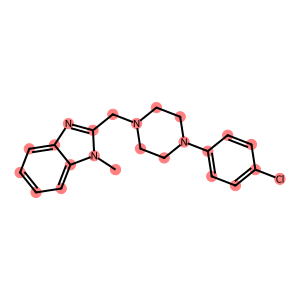

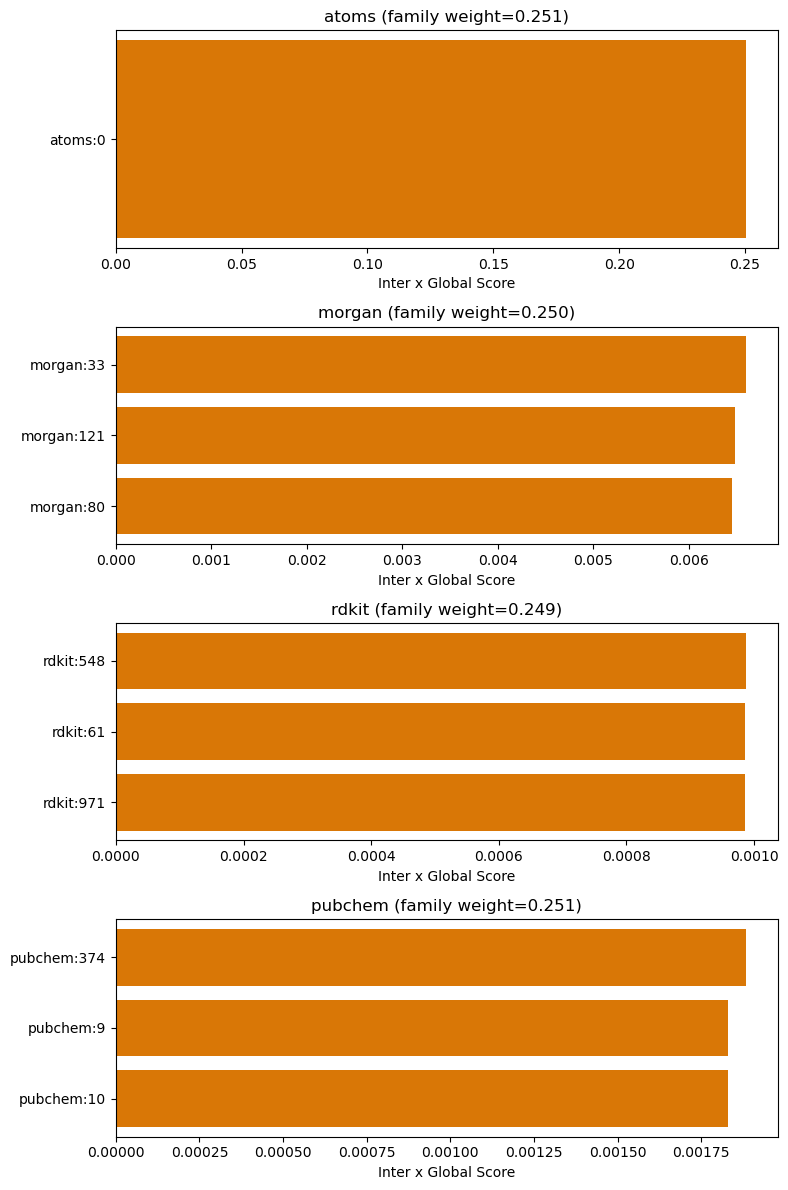

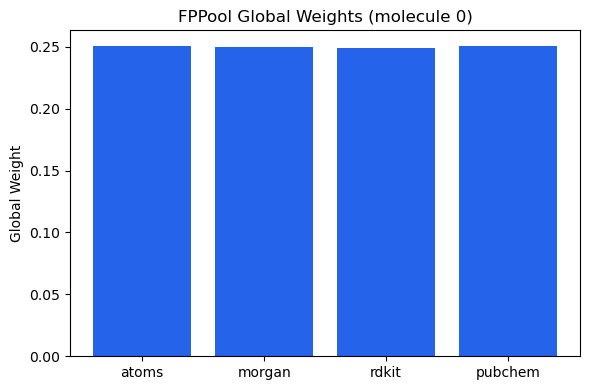

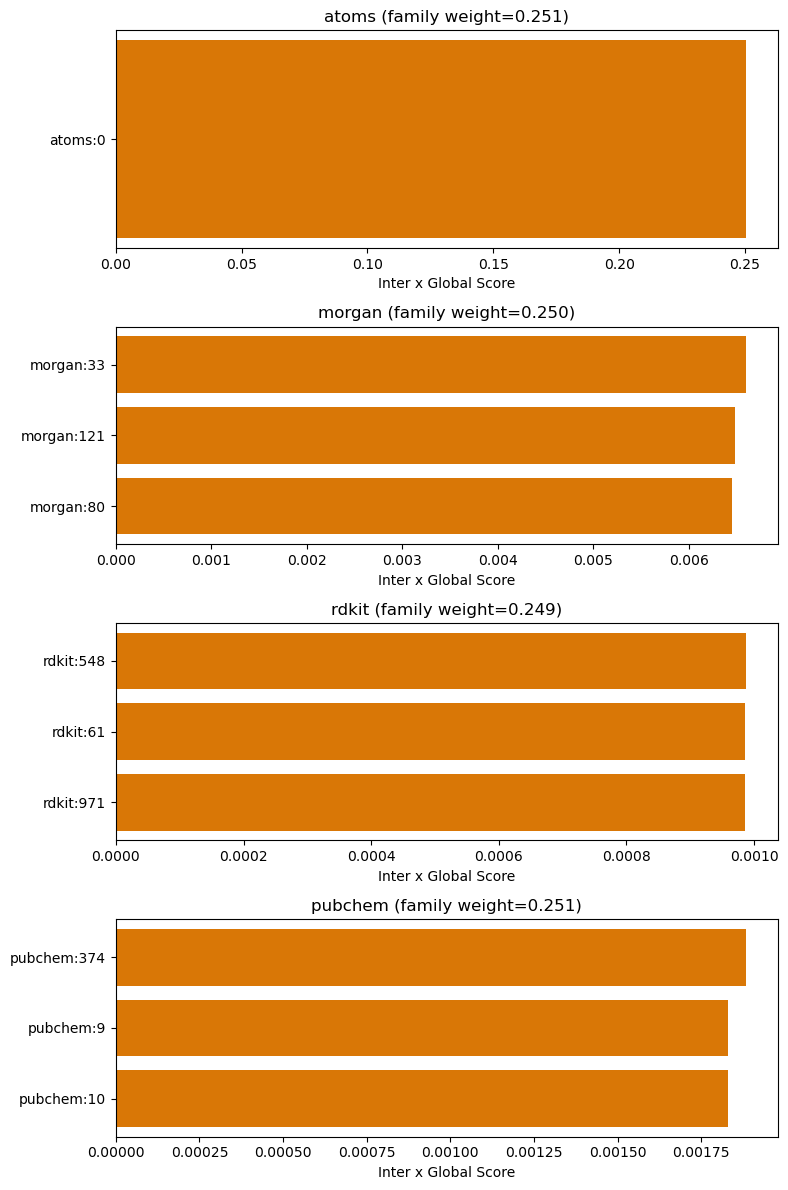

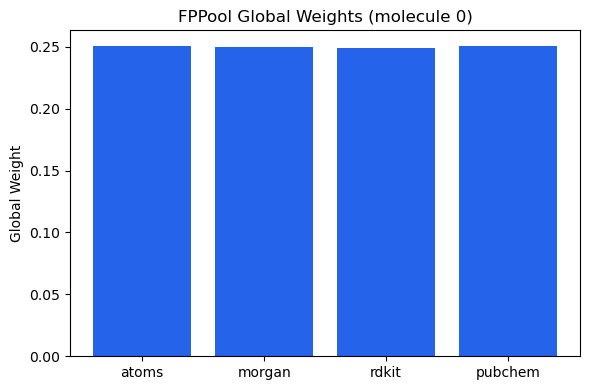

In [7]:
highlighted = draw_fppool_inner_explanations(batch_mols[0], example_explanation, top_k=1)
display(highlighted[0])
inter_fig = plot_fppool_inter_summary(example_explanation, top_k_bits=3)
global_fig = plot_fppool_global_weights(example_explanation)
display(inter_fig)
display(global_fig)
